### Required Discussion 19:1: Building a Recommender System with SURPRISE

This discussion focuses on exploring additional algorithms with the `Suprise` library to generate recommendations.  Your goal is to identify the optimal algorithm by minimizing the mean squared error using cross validation. You are also going to select a dataset to use from [grouplens](https://grouplens.org/datasets/movielens/) example datasets.  

To begin, head over to [grouplens](https://grouplens.org/datasets/movielens/) and examine the different datasets available.  Choose one so that it is easy to create the data as expected in `Surprise` with user, item, and rating information.  Then, compare the performance of at least the `KNNBasic`, `SVD`, `NMF`, `SlopeOne`, and `CoClustering` algorithms to build your recommendations.  For more information on the algorithms see the documentation for the algorithm package [here](https://surprise.readthedocs.io/en/stable/prediction_algorithms_package.html).

Share the results of your investigation and include the results of your cross validation and a basic description of your dataset with your peers.


In [ ]:
# 1. Uninstall the existing NumPy and Surprise
!pip uninstall -y numpy scikit-surprise

# 2. Install a compatible NumPy (1.26.4 is the stable 1.x bridge) and Surprise
!pip install numpy==1.26.4 scikit-surprise

# 3. Force a session restart (this clears the old NumPy from memory)
import os
os._exit(0)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 6.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 74.4 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554982 sha256=a65b2a7268ae0ae4e9cbf6da864590d92cdafc2ef2cbf6a3e441d4980b7d6112
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires n

In [ ]:
import numpy
import surprise
print(f"NumPy version: {numpy.__version__}")
print("Surprise imported successfully!")

NumPy version: 1.26.4
Surprise imported successfully!


In [ ]:
from surprise import Dataset, Reader, SVD, NMF, KNNBasic, SlopeOne, CoClustering
from surprise.model_selection import cross_validate

import pandas as pd

### Data

This dataset (ml-latest-small) describes 5-star rating and free-text tagging activity from MovieLens, a movie recommendation service. It contains 100836 ratings and 3683 tag applications across 9742 movies. These data were created by 610 users between March 29, 1996 and September 24, 2018. This dataset was generated on September 26, 2018.

Users were selected at random for inclusion. All selected users had rated at least 20 movies. No demographic information is included. Each user is represented by an id, and no other information is provided.

To acknowledge use of the dataset in publications, please cite the following paper:

F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872



In [ ]:
movie_reviews = pd.read_csv("/content/sample_data/ml-surprise-ratings.csv")
movie_reviews.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
movie_reviews.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [ ]:
movie_reviews["rating"].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

Choose one so that it is easy to create the data as expected in `Surprise` with user, item, and rating information.  Then, compare the performance of at least the `KNNBasic`, `SVD`, `NMF`, `SlopeOne`, and `CoClustering` algorithms to build your recommendations.  For more information on the algorithms see the documentation for the algorithm package [here](https://surprise.readthedocs.io/en/stable/prediction_algorithms_package.html).

Share the results of your investigation and include the results of your cross validation and a basic description of your dataset with your peers.


In [ ]:
# define a rating scale at 0.5 intervals
reader = Reader(rating_scale=(0.5, 5))
sf= Dataset.load_from_df(movie_reviews[["userId","movieId","rating"]], reader)
sf

In [ ]:
# Train and test set
train= sf.build_full_trainset()
test= train.build_testset()

In [ ]:
#Build the model
model = SVD(n_epochs=10000, biased=False , n_factors=2)

In [ ]:
# Fit the SVD model
model.fit(train)

# Test set
predictions_list=model.test(test)
predictions_list[:5]

In [ ]:
len(predictions_list)

In [ ]:
 # prepare model list of `KNNBasic`, `SVD`, `NMF`, `SlopeOne`, and `CoClustering` as name value pair
models = {
    "KNNBasic": KNNBasic(),
    "SVD": SVD(),
    "NMF": NMF(),# similat to above but item and user factors are both positive .
    "SlopeOne": SlopeOne(),# simple straight forward collaborative filtering based on average diff of rratings by 2 users on relevant items (with at least one common user)
    "CoClustering": CoClustering()# simultaneously creates clusters of items and users in collaborative filtering , optimizing by calc avg rating of cluster , items and users. Def number of u and i clusters is 3 , n_epoch=20.
}
models.items()

dict_items([('KNNBasic', <surprise.prediction_algorithms.knns.KNNBasic object at 0x79036aad66f0>), ('SVD', <surprise.prediction_algorithms.matrix_factorization.SVD object at 0x79036ad13d40>), ('NMF', <surprise.prediction_algorithms.matrix_factorization.NMF object at 0x79036ad12720>), ('SlopeOne', <surprise.prediction_algorithms.slope_one.SlopeOne object at 0x79036ad13d70>), ('CoClustering', <surprise.prediction_algorithms.co_clustering.CoClustering object at 0x79038c35f5f0>)])

In [ ]:
# Perform cross validation on the various models and the best model on basis of minimum MSE

In [ ]:
cross_val_results = cross_validate(model,sf,cv=10, measures=['MSE'])

In [ ]:
# Find mean of values inside this tuple
cross_val_results['test_mse'].mean()

In [ ]:
movie_reviews.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
from datetime import datetime
from timeit import default_timer as timer
best_models = {}
results_cv = []
for name, model in models.items():

    start_time = timer()
    print(f"Training model on entire dataset and finding score for {name}...at ", datetime.now(),  " UTC")
    model.fit(sf.build_full_trainset())
    train_time_model = timer() - start_time

    # Compute cross validation metrics on train and test sets
    # Store results
    cross_val_results = cross_validate(model, sf, measures=['RMSE'])
    print(f"cv results score for {name}...at ", datetime.now(),  " UTC", cross_val_results)
    results_cv.append({"model": f" {name}",
                       "best_rmse_cv": cross_val_results['test_rmse'].mean(),
                       "train_time": train_time_model,
                       })

Training model on entire dataset and finding score for KNNBasic...at  2026-05-06 22:13:01.527774  UTC
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
cv results score for KNNBasic...at  2026-05-06 22:13:12.079766  UTC {'test_rmse': array([0.95249268, 0.95540749, 0.9510915 , 0.93839027, 0.94884018]), 'fit_time': (0.16649079322814941, 0.17863225936889648, 0.27053070068359375, 0.17023611068725586, 0.16809606552124023), 'test_time': (1.2991836071014404, 1.4038143157958984, 2.369262933731079, 1.3817899227142334, 1.5635120868682861)}
Training model on entire dataset and finding score for SVD...at  2026-05-06 

In [ ]:
results_cv_df = pd.DataFrame(results_cv).sort_values("best_rmse_cv").reset_index(drop=True)
results_cv_df.sort_values(by="best_rmse_cv",inplace=True)
results_cv_df


In [ ]:
results_cv_df = pd.DataFrame(results_cv).sort_values("best_rmse_cv").reset_index(drop=True)
results_cv_df.sort_values(by="best_rmse_cv",inplace=True)
results_cv_df


,model,best_mse_cv,Train Time
0,SVD,0.874405,1.608487
1,SlopeOne,0.901788,5.953558
2,NMF,0.921802,2.431989
3,CoClustering,0.947593,2.198464
4,KNNBasic,0.947861,0.552561


In [26]:
# Run 2
results_cv_df = pd.DataFrame(results_cv).sort_values("best_rmse_cv").reset_index(drop=True)
results_cv_df.sort_values(by="best_rmse_cv",inplace=True)
results_cv_df


,model,best_rmse_cv,train_time
0,SVD,0.873839,1.733013
1,SlopeOne,0.902092,10.263129
2,NMF,0.922384,2.911170
3,CoClustering,0.944024,2.332197
4,KNNBasic,0.949244,0.308899


/tmp/ipykernel_25888/2601030205.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="model", y="best_rmse_cv", data=results_cv_df, palette="Set2")
/tmp/ipykernel_25888/2601030205.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="model", y="train_time", data=results_cv_df,palette="Set3")


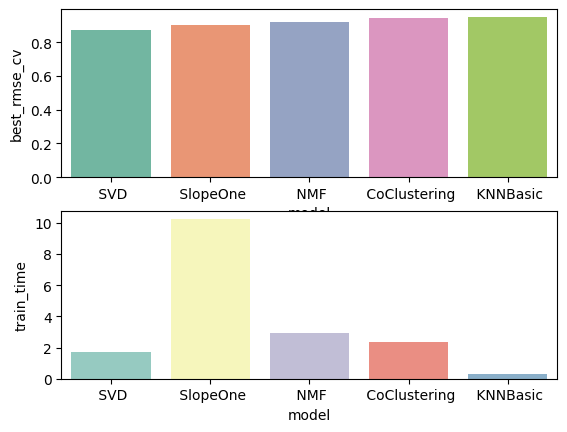

In [32]:
# Plot the model and best_rmse_cv as barplot and against train time as subplots ,
import seaborn as sns
import matplotlib.pyplot as plt

plt.subplot(211)
# Put different colors for each model
sns.barplot(x="model", y="best_rmse_cv", data=results_cv_df, palette="Set2")
plt.subplot(212)
sns.barplot(x="model", y="train_time", data=results_cv_df,palette="Set3")
plt.show()